 kx    ky    kz      Z_xy^{-+} (numeric)       Z_xy^{-+} (analytical)
 0.20  0.30  0.40     0.384197251401         0.384197251401
 1.00  0.50  0.00     0.357770876400         0.357770876400
 0.00  0.40  0.50     0.000000000000         0.000000000000


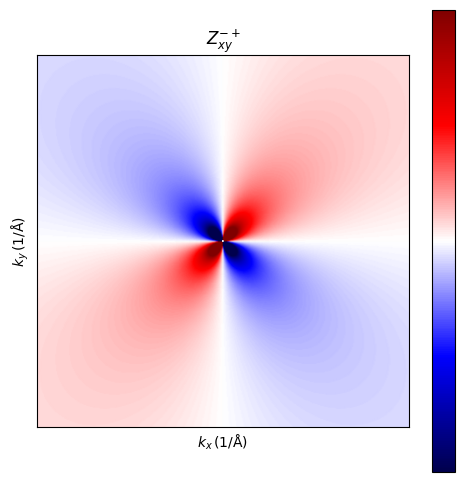

In [ ]:
import numpy as np

sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)

def H_weyl(kx, ky, kz, vF=1.0):
    return vF * (kx * sx + ky * sy + kz * sz)

def dH_dkx(vF=1.0): return vF * sx
def dH_dky(vF=1.0): return vF * sy
def dH_dkz(vF=1.0): return vF * sz

def diagonalize_and_assign(H):
    evals, evecs = np.linalg.eigh(H)
    if evals[0] < evals[1]:
        return evals[0], evals[1], evecs[:, 0], evecs[:, 1]
    else:
        return evals[1], evals[0], evecs[:, 1], evecs[:, 0]


def compute_Z_xy_minus_plus(kx, ky, kz, vF=1.0, eps=1e-12):
    k_norm = np.sqrt(kx**2 + ky**2 + kz**2)
    if k_norm < eps:
        return 0.0

    H = H_weyl(kx, ky, kz, vF)
    dHkx = dH_dkx(vF)
    sigma_y = sy

    E_minus, E_plus, u_minus, u_plus = diagonalize_and_assign(H)
    denom = (E_plus - E_minus)
    if abs(denom) < eps:
        return 0.0


    elem_kx_m_p = np.vdot(u_minus, dHkx @ u_plus)
    elem_kx_p_m = np.vdot(u_plus,  dHkx @ u_minus)
    r_x_mp = 1j * elem_kx_m_p / denom
    r_x_pm = 1j * elem_kx_p_m / (E_minus - E_plus)


    sigma_y_pm = np.vdot(u_plus,  sigma_y @ u_minus)
    sigma_y_mp = np.vdot(u_minus, sigma_y @ u_plus)

    Z_xy_mp = 1j * (r_x_mp * sigma_y_pm - r_x_pm * sigma_y_mp)
    return Z_xy_mp.real

def analytical_Z_xy(kx, ky, kz, eps=1e-12):
    k_norm_sq = kx**2 + ky**2 + kz**2
    if k_norm_sq < eps:
        return 0.0
    return (kx * ky) / (k_norm_sq**1.5)

# Few points
points = [
    (0.2, 0.3, 0.4),
    (1.0, 0.5, 0.0),
    (0.0, 0.4, 0.5),
]

print(" kx    ky    kz      Z_xy^{-+} (numeric)       Z_xy^{-+} (analytical)")
for kx, ky, kz in points:
    z_num = compute_Z_xy_minus_plus(kx, ky, kz, vF=1.0)
    z_ana = analytical_Z_xy(kx, ky, kz)
    print(f"{kx:5.2f} {ky:5.2f} {kz:5.2f}    {z_num: .12f}        {z_ana: .12f}")

    import matplotlib.pyplot as plt

N = 400
kx_range = np.linspace(-1.0, 1.0, N)
ky_range = np.linspace(-1.0, 1.0, N)
KX, KY = np.meshgrid(kx_range, ky_range)

kz_fixed = 0.0

# Z computation
Z_numeric = np.zeros_like(KX)
for i in range(N):
    for j in range(N):
        Z_numeric[i, j] = compute_Z_xy_minus_plus(KX[i, j], KY[i, j], kz_fixed,
                                                  vF=1.0, eps=1e-12)

# masking
k = 0.005
R = np.sqrt(KX**2 + KY**2 + kz_fixed**2)
Z_numeric[R < k] = np.nan

# clipping
clip_val = 5.0
Z_plot = np.clip(Z_numeric, -clip_val, clip_val)

# plot
plt.figure(figsize=(6,6))
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.pcolormesh(KX, KY, Z_plot, cmap='seismic', shading='gouraud',
               vmin=-clip_val, vmax=clip_val)
plt.gca().set_aspect('equal')
plt.xticks([])
plt.yticks([])
plt.xlabel(r"$k_x\,(1/\mathrm{\AA})$")
plt.ylabel(r"$k_y\,(1/\mathrm{\AA})$")
cbar = plt.colorbar()
cbar.set_ticks([])
plt.title(f" $Z_{{xy}}^{{-+}}$ ")
plt.show()
